In [12]:
import tensorflow as tf
from tensorflow import keras
import matplotlib
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split


data = keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = data.load_data()


X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)


X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0


In [16]:
# number of images and shape
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

# memory usage in MB
print("X_train memory (MB):", X_train.nbytes / 1024**2)
print("X_test memory (MB):", X_test.nbytes / 1024**2)


X_train: (48000, 28, 28)
y_train: (48000,)
X_test: (10000, 28, 28)
y_test: (10000,)
X_train memory (MB): 287.109375
X_test memory (MB): 59.814453125


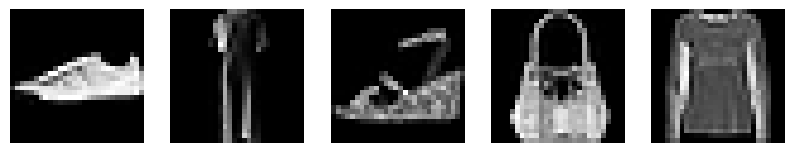

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.axis('off')
plt.show()


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Flatten(input_shape=(28, 28)),

    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(10, activation='softmax')
])

model.compile(optimizer=Adam(1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


c:\Users\User\Desktop\machine-learning\dl_env\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True,
    min_delta=0.001  # stop if improvement < 0.001

)


In [10]:
history = model.fit(X_train, y_train, epochs=30, callbacks=[early_stop])

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.7803 - loss: 0.6277
Epoch 2/30
  11/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.8455 - loss: 0.4468

c:\Users\User\Desktop\machine-learning\dl_env\lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_accuracy` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8221 - loss: 0.4925
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.8335 - loss: 0.4617
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.8416 - loss: 0.4393
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.8479 - loss: 0.4241
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.8510 - loss: 0.4125
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.8550 - loss: 0.4019
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8576 - loss: 0.3929
Epoch 9/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8614 - loss: 0.3823
Epoch 10/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.8609 - loss: 0.3800
Epoch 11/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8624 - loss: 0.3734
Epoch 12/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8671 - loss: 0.3636
Epoch 13/30
1500/1

In [11]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8808 - loss: 0.3375


[0.33751481771469116, 0.8808000087738037]